<a href="https://colab.research.google.com/github/ZingZing001/CSLabTraining/blob/main/CS721_Lab1_V4_tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center>  Machine Intelligence and Deep Learning (COMPSYS 721)
# <center> Department of Electrical, Computer, and Software Engineering


# <center> Lab 1: Image classification using convolutional neural network (CNN)

## Example of image classification model using CNN:

The following code does the following:

Loads the CIFAR-10 dataset. Filters out images and labels for birds, cats, and dogs from the original dataset. Remaps the labels for birds, cats, and dogs from their original CIFAR-10 labels to 0, 1, and 2 respectively. Splits the filtered training dataset into a final training, a validation, and testing sets. Prints the shapes of the final training, validation, and test datasets.

CIFAR-10 is a dataset containing 60,000 color images of resolution 32x32 pixels in 10 classes, with 6,000 images per class. The classes are: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

By filtering for birds, cats, and dogs, you're effectively reducing the dataset to 18,000 images (6,000 for each of the three classes). We split 4000 images/class for the training, 1,000 images/class for validation, and 1,000 images/class for testing.

After remapping the labels, the new labels are:

Bird: 0   Cat: 1    Dog: 2


The printed shapes will give you an idea of the dimensions and size of the datasets:

x_train_final.shape: This should output (12000, 32, 32, 3), which indicates 12,000 images for the 3 classes, each of size 32x32 pixels with 3 color channels (RGB).

y_train_final.shape: This should output (12000, 1), indicating there are 12,000 labels corresponding to the 12,000 training images.

Similarly, for the validation data we have:
x_val.shape: (3000, 32, 32, 3) y_val.shape: (3000, 1)

And for the test data:
x_test_filtered.shape: (3000, 32, 32, 3) y_test_filtered.shape: (3000, 1)

This organized data is now ready for training a neural network model.


In [ ]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

# 1. Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Filter out birds, cats, and dogs from training and test sets
train_indices = np.where((y_train == 2) | (y_train == 3) | (y_train == 5))[0]
test_indices = np.where((y_test == 2) | (y_test == 3) | (y_test == 5))[0]

x_train_filtered = x_train[train_indices]
y_train_filtered = y_train[train_indices]

x_test_filtered = x_test[test_indices]
y_test_filtered = y_test[test_indices]

# Convert labels: bird (2) -> 0, cat (3) -> 1, dog (5) -> 2 for easier processing later
label_map = {2: 0, 3: 1, 5: 2}

y_train_filtered = np.vectorize(label_map.get)(y_train_filtered)
y_test_filtered = np.vectorize(label_map.get)(y_test_filtered)

# 3. Split filtered training data into final training and validation sets
x_train_final, x_val, y_train_final, y_val = train_test_split(x_train_filtered, y_train_filtered, test_size=0.2, random_state=42, stratify=y_train_filtered)

print("Training data shapes:")
print(x_train_final.shape)
print(y_train_final.shape)

print("\nValidation data shapes:")
print(x_val.shape)
print(y_val.shape)

print("\nTest data shapes:")
print(x_test_filtered.shape)
print(y_test_filtered.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shapes:
(12000, 32, 32, 3)
(12000, 1)

Validation data shapes:
(3000, 32, 32, 3)
(3000, 1)

Test data shapes:
(3000, 32, 32, 3)
(3000, 1)


### Plot few images from each class for verification

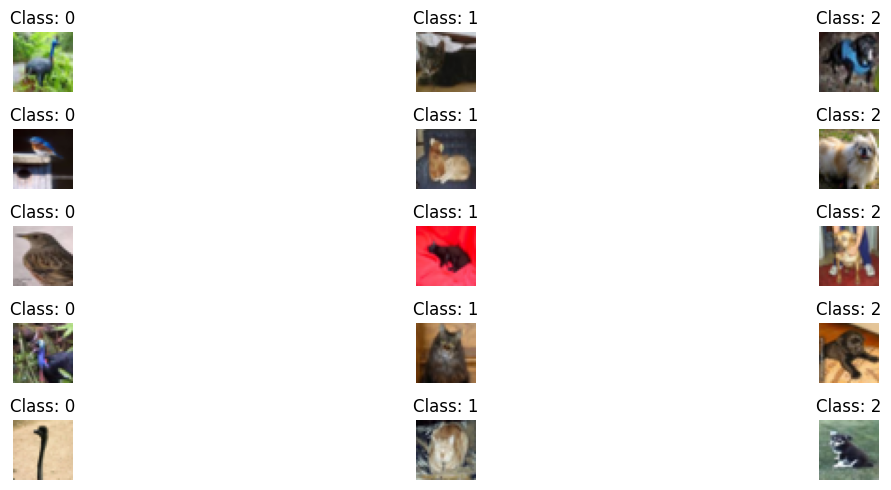

In [ ]:
import matplotlib.pyplot as plt

# Function to plot images
def plot_images(images, labels, classes, num=5):
    fig, axes = plt.subplots(num, len(classes), figsize=(15, 5))
    for i, label in enumerate(classes):
        # Filter images of a specific label
        idxs = np.where(labels == label)[0][:num]

        for j, idx in enumerate(idxs):
            if len(classes) > 1:
                ax = axes[j, i]
            else:
                ax = axes[j]
            ax.imshow(images[idx])
            ax.set_title(f"Class: {label}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()

# Class labels after mapping: bird (0), cat (1), dog (2)
classes = [0, 1, 2]
plot_images(x_train_filtered, y_train_filtered.squeeze(), classes)

Creating a convolutional neural network (CNN) to classify images as dogs, cats, or birds requires a few key steps:

Data Collection: You'll need labeled images of dogs, cats, and birds. There are several public datasets like CIFAR-10 or Kaggle's Dogs vs. Cats competition dataset.

Data Preprocessing: Normalize the images, resize them to a consistent size, and split them into training, validation, and test sets.

Model Building: Design the CNN architecture.

Training: Train the model on your training set.

Evaluation: Evaluate the model's performance on the validation and test sets.

Below is a simple CNN using TensorFlow and Keras for this classification problem:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from sklearn.model_selection import train_test_split

# Load CIFAR-10 data and preprocess
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

train_indices = np.where((y_train == 2) | (y_train == 3) | (y_train == 5))[0]
test_indices = np.where((y_test == 2) | (y_test == 3) | (y_test == 5))[0]

x_train_filtered = x_train[train_indices]
y_train_filtered = y_train[train_indices]
x_test_filtered = x_test[test_indices]
y_test_filtered = y_test[test_indices]

label_map = {2: 0, 3: 1, 5: 2}
y_train_filtered = np.vectorize(label_map.get)(y_train_filtered)
y_test_filtered = np.vectorize(label_map.get)(y_test_filtered)

x_train_final, x_val, y_train_final, y_val = train_test_split(x_train_filtered, y_train_filtered, test_size=0.2, random_state=42, stratify=y_train_filtered)

# Normalize the data
x_train_final = x_train_final.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test_filtered = x_test_filtered.astype('float32') / 255.0

# Build the CNN model
model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_final, y_train_final, epochs=20, validation_data=(x_val, y_val))

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test_filtered, y_test_filtered, verbose=2)
print("\nTest accuracy:", test_acc)

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 71ms/step - accuracy: 0.4835 - loss: 1.0068 - val_accuracy: 0.5287 - val_loss: 0.9317
Epoch 2/20
101/375 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.5557 - loss: 0.9352

KeyboardInterrupt: 

In the plots depicting the accuracy and loss over epochs for both training and validation:

Horizontal Axis (X-axis): Represents the epochs. An epoch is one complete forward and backward pass of all the training samples through the neural network.

Vertical Axis (Y-axis):

For the accuracy plot: Represents the accuracy (a value between 0 and 1). It measures the proportion of correct predictions out of total predictions.
For the loss plot: Represents the loss value. This is a measure of the error or difference between the predicted output and the actual output.
So, in summary:

The accuracy plot shows how well the model is classifying the data over epochs.
The loss plot provides insight into how the error between the predicted and actual outputs is decreasing over epochs.
By comparing the training and validation curves, you can gain insights into the model's performance and potential issues, such as overfitting (when the training accuracy/loss continues to improve significantly, but the validation accuracy/loss stagnates or worsens).

Testing the model:

Randomly select a number (num_images) of images from the test set (x_test_filtered).
Use the model to predict the class labels for these images.
Display the images alongside their true and predicted labels.
Make sure this code is run after the model training code to ensure the model and dataset variables (x_test_filtered, y_test_filtered) are already defined. Adjust num_images to display more or fewer images as needed.

In [ ]:
# Load a few images from the test set
num_images = 10
random_indices = np.random.choice(len(x_test_filtered), size=num_images, replace=False)
sample_images = x_test_filtered[random_indices]
sample_labels = y_test_filtered[random_indices].squeeze()  # squeeze labels to get 1D array

# Get model predictions
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

# Map our label indices back to actual class names
label_names = {0: 'Bird', 1: 'Cat', 2: 'Dog'}

# Plot the images alongside predictions
# Plot the images alongside predictions
plt.figure(figsize=(5 * num_images, 5 * num_images))
for i, (image, true_label, pred_label) in enumerate(zip(sample_images, sample_labels, predicted_labels)):
    ax = plt.subplot(num_images, 1, i + 1)
    ax.imshow(image)
    ax.set_title(f"True: {label_names[true_label]}, Pred: {label_names[pred_label]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### The structure of the datasets if imported
Points to Consider:
Labels from Directories: Tools like ImageDataGenerator.flow_from_directory in Keras will automatically infer class labels from the subdirectory names within "train", "validation", or "test". This means your labels (i.e., "dog", "cat", "bird") should be the names of the subdirectories.

Shuffling: Typically, training data should be shuffled for better generalization. Testing data, on the other hand, is often not shuffled, especially if you want to analyze specific predictions post-hoc.

Data Augmentation: It's common to apply data augmentation techniques only on the training dataset to artificially expand the variety of training examples. Libraries like Keras provide easy-to-use tools for on-the-fly data augmentation during training.

Validation Data: It's good practice to have a validation dataset in addition to the training and test datasets. The validation set is used during model training to monitor the model's performance on unseen data and tune hyperparameters, without touching the test set.

Remember, keeping a clean, organized dataset structure is crucial. It not only makes the data-loading process more straightforward but also minimizes errors that can arise from mislabeled data or data leakage.

dataset_directory/
│
├── train/
│   ├── dog/
│   │   ├── dog1.jpg
│   │   ├── dog2.jpg
│   │   ├── ...
│   ├── cat/
│   │   ├── cat1.jpg
│   │   ├── cat2.jpg
│   │   ├── ...
│   ├── bird/
│   │   ├── bird1.jpg
│   │   ├── bird2.jpg
│   │   ├── ...
│
├── validation/
│   ├── dog/
│   │   ├── dog1.jpg
│   │   ├── ...
│   ├── cat/
│   │   ├── cat1.jpg
│   │   ├── ...
│   ├── bird/
│   │   ├── bird1.jpg
│   │   ├── ...
│
├── test/
    ├── dog/
    │   ├── dog1.jpg
    │   ├── ...
    ├── cat/
    │   ├── cat1.jpg
    │   ├── ...
    ├── bird/
        ├── bird1.jpg
        ├── ...


## Lab tasks: Creating a four-class classifier using CNN to categorize transportation vehicles
In this part,
- You need to develop a CNN model to classify four types of transportation vehicles, namely airplane, automobile, ship, and truck.
- Use images in CIFAR-10 dataset to finish the tasks.

Please do:
- Print the necessary values, including but not limited to shapes and labels, to defence your work.
- Keep your code and results tidy and readable for signing off.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, AveragePooling2D, Dropout, BatchNormalization, ReLU

**Task 1:** Dataset preparation (0.5%)
- Load CIFAR-10 dataset and filter out the interested classes.
- Remap the labels.

Here's the labels according to their github!

[Screenshot 2026-03-24 at 1.51.41 PM.png](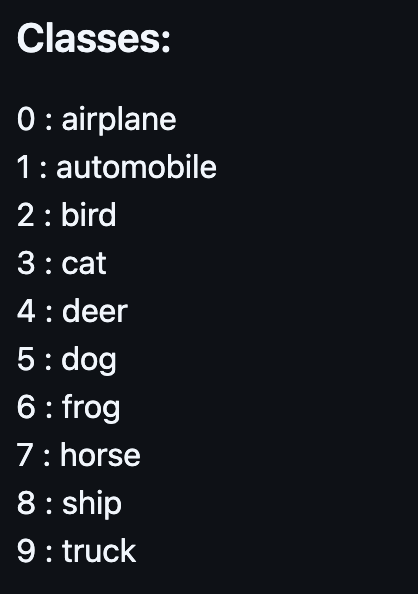)

In [ ]:
# TODO: Load CIFAR-10 data and filter out the interested classes, which are airplane, automobile, ship, and truck
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# The image classes are 0 (airplane), 1(automobile), 8(ship) ,9(truck). And we split the dataset for training and testing
train_indices = np.where((y_train == 0) | (y_train == 1) | (y_train == 8) | (y_train == 9))[0]
test_indices = np.where((y_test == 0) | (y_test == 1) | (y_test == 8) | (y_test == 9)) [0]

x_train_filtered = x_train[train_indices]
y_train_filtered = y_train[train_indices]

x_test_filtered = x_test[test_indices]
y_test_filtered = y_test[test_indices]

# 50000 images that is 32x32 pixels with 3 layers (RGB), and output of 50000 numbers
print(x_train.shape, y_train.shape)
# 10000 images that is 32x32 pixels with 3 layers (RGB), and output of 10000 numbers
print(x_test.shape, y_test.shape)

# TODO: Remap the labels of airplane, automobile, ship, and truck to 0, 1, 2, and 3 respectively.
label_map = {0: 0, 1: 1, 8: 2, 9: 3}
y_train_filtered = np.vectorize(label_map.get)(y_train_filtered)
y_test_filtered = np.vectorize(label_map.get)(y_test_filtered)

# Actual images with classes we want
print(y_train_filtered.shape)
print(y_test_filtered.shape)



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 50s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)
(20000, 1)
(4000, 1)


**Task 2:** Data splitting and preprocessing (0.5%)
- Split the original training set into training and validation sets with a ratio of 80-20.
- Convert the values into 32-bit floats and apply max-min normalization.

Training data shapes:
(16000, 32, 32, 3)
(16000, 1)

Validation data shapes:
(4000, 32, 32, 3)
(4000, 1)

Test data shapes:
(4000, 32, 32, 3)
(4000, 1)


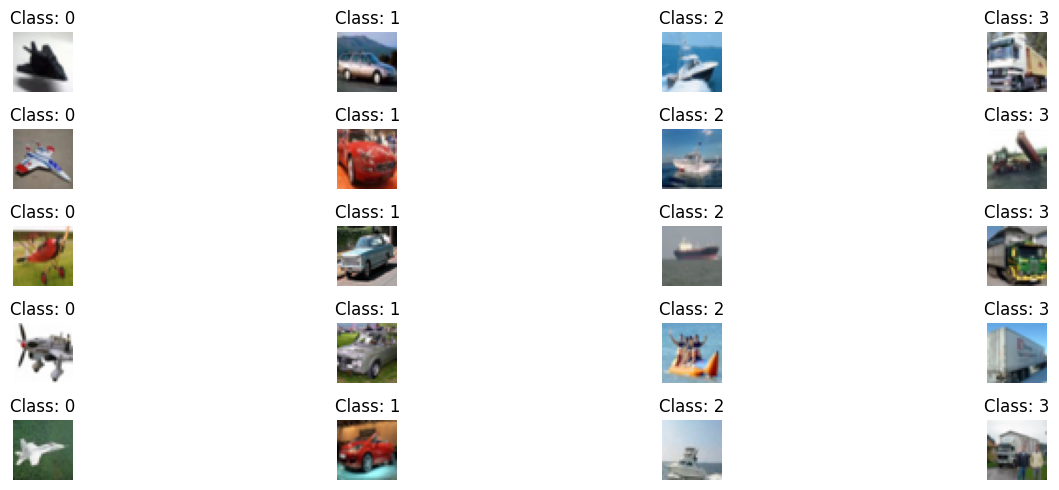

In [ ]:
import matplotlib.pyplot as plt
# TODO: Split the original training set into training and validation sets with a ratio of 80-20.
x_train_final, x_val, y_train_final, y_val = train_test_split(x_train_filtered, y_train_filtered, test_size=0.2, stratify=y_train_filtered)
print("Training data shapes:")
print(x_train_final.shape)
print(y_train_final.shape)

print("\nValidation data shapes:")
print(x_val.shape)
print(y_val.shape)

print("\nTest data shapes:")
print(x_test_filtered.shape)
print(y_test_filtered.shape)


# Function to plot images
def plot_images(images, labels, classes, num=5):
    fig, axes = plt.subplots(num, len(classes), figsize=(15, 5))
    for i, label in enumerate(classes):
        # Filter images of a specific label
        idxs = np.where(labels == label)[0][:num]

        for j, idx in enumerate(idxs):
            if len(classes) > 1:
                ax = axes[j, i]
            else:
                ax = axes[j]
            ax.imshow(images[idx])
            ax.set_title(f"Class: {label}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()

# Class labels after mapping: bird (0), cat (1), dog (2)
classes = [0, 1, 2, 3]
plot_images(x_train_filtered, y_train_filtered.squeeze(), classes)
# TODO: Convert the values into 32-bit floats and apply max-min normalization.
x_train_final = x_train_final.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test_filtered = x_test_filtered.astype('float32') / 255.0


**Task 3:** Build and train a CNN model (1.5%)
- Build a CNN model.
- Use "for" loops to adjust hyperparameters and train the model. Based on the accuracy and loss curves, determine which combination of hyperparameters yields the best results.
- Use the combination of hyperparameters to train the model with the highest validation accuracy.

In [ ]:
# TODO: Build a CNN model.
# TODO: Use "for" loops to adjust hyperparameters and retrain the model. Based on the accuracy and loss curves, determine which combination of hyperparameters yields the best results.

# First I want to tune the kernel size as it is one of the hyperparameter while keeping the others(numbers of blocks,dropoutrate, number of filter and the numbers of the DNN)
# Kernel (3, 3): val_accuracy = 0.8375
# Kernel (5, 5): val_accuracy = 0.8493
# Kernel (7, 7): val_accuracy = 0.8310

for kernel_size in [(5,5)]:
    model = Sequential([
        Input(shape=(32, 32, 3)),

        # first convolutional block
        Conv2D(32,                      # the number of filters
               kernel_size,             # the shape of each filter
               activation='relu',
               padding='same'),

        MaxPooling2D(2, 2),
        Dropout(0.25),

        # second convolutional block
        Conv2D(64, kernel_size, activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Added a third convolutional block
        Conv2D(128, kernel_size, activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # flatten layer
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(4, activation='softmax')
    ])

    model.compile(loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

    history = model.fit(x_train_final, y_train_final,
                    epochs=10,
                    validation_data=(x_val, y_val)) # validation_data that include labels

    val_accuracy = history.history['val_accuracy'][-1]
    print(f"Kernel {kernel_size}: val_accuracy = {val_accuracy:.4f}")

# TODO: Use the combination of hyperparameters to train the model with the highest validation accuracy.

# TODO: Answer the question
print("Q: What are the hyperparameters in your case?")
print("A: ...")

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.5038 - loss: 1.1216 - val_accuracy: 0.5847 - val_loss: 1.0168
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.6802 - loss: 0.8071 - val_accuracy: 0.7455 - val_loss: 0.6485
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 75s 149ms/step - accuracy: 0.7479 - loss: 0.6552 - val_accuracy: 0.8012 - val_loss: 0.5134
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 127ms/step - accuracy: 0.7867 - loss: 0.5720 - val_accuracy: 0.8315 - val_loss: 0.4574
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 127ms/step - accuracy: 0.8064 - loss: 0.5319 - val_accuracy: 0.8528 - val_loss: 0.4111
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 129ms/step - accuracy: 0.8184 - loss: 0.5039 - val_accuracy: 0.8487 - val_loss: 0.4529
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 138ms/step - accuracy: 0.8316 - loss: 0.4679 - val_accuracy: 0.8537 - val_loss: 0.4078
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 130ms/step - accuracy: 0.8393 - loss: 0

**Task 4:** Testing the model (1.5%)
- Evaluate your model on the entire testing set.
- Repeat Task 3 until you get a test accuracy higher than 90%. If you are confident on the hyperparameters but the testing accuracy is not satisfactory, that means the model structure needs to be optimized.
- Randomly select 10 images from the testing set, predict their labels, and compare the predicted labels to the true labels.

In [ ]:
model.summary()
keras.utils.plot_model(model)
# TODO: Evaluate your model on the entire testing set.
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title("Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

test_acc = model.evaluate(x_test_filtered, y_test_filtered)[1]
# TODO: Repeat Task 3 until you get a test accuracy higher than 90%.
if test_acc < 0.9:
    print("Your targeted test accuracy is 90%. Please achieve this target by adjusting your model in Task 3!")
else:
    print("You have achieved the goal of reaching a 90% test accuracy!")

# TODO: Randomly select 10 images from the testing set, predict their labels, and compare the predicted labels to the true labels.